# SPC tornado, hail, and wind databases

The NWS Storm Prediction Center (SPC) keeps a database of every U.S. tornado
since 1950, drawn from NWS Storm Data, and publishes it as plain CSV: one
file per year from 2008, wider files before that. One row is one tornado,
with its touchdown date and time, EF or F rating, injuries, fatalities, loss,
start and end coordinates, and path length and width; a tornado that crossed
a state line gets an extra row per state. SPC's hail and wind databases share
the layout.

This walkthrough pulls the 2024 tornado file and counts the year's tornadoes
by month and rating. It needs `usdata[pandas]` and matplotlib; the file is
about 230 KB and the run takes a few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T05:59:07+00:00
usdata 0.26.0; pandas 3.0.6


## Select

The manifest asks for all of 2024, which selects SPC's `2024_torn.csv`. The
dates only choose files: a single day in 2024 would select the same whole
file, and a day in the 1970s would select the whole 1970s decade file. There
is no server-side filter by state, place, or column. `params: {table: hail}`
or `{table: wind}` would select the other two databases instead.

In [2]:
print(manifest.read_text())

name: spc-tornadoes-2024
sources:
  - dataset: noaa:spc-tornado-reports
    start: 2024-01-01
    end: 2024-12-31



## What arrives

One CSV. SPC revises its files in place as Storm Data is finalized, and the
file name never changes, so the checksum in the `dataset.lock.json` the first
pull writes is the only record of which revision you analysed.

In [3]:
result = pull(manifest)
(item,) = result.fetched
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)

File: 2024_torn.csv
Bytes: 230094
Source: https://www.spc.noaa.gov/wcm/data/2024_torn.csv
Retrieved (UTC): 2026-09-24T05:59:08+00:00
Checksum: sha256:fe7cc5b353f251d385fecaf393529586e0a2cd5f200173affa451a952c2cac40


## Open

The generic CSV reader returns a DataFrame. FIPS codes are unpadded integers
in the file, so `dtype` keeps the state and first county code as text, and
`parse_dates` turns `date` into a timestamp.

- Time: `date` and `time` are the touchdown in the zone `tz` names. Code `3`
  is Central Standard Time (UTC-6, no daylight saving) for every tornado,
  wherever it happened; add six hours for UTC.
- Place: `st` and `stf` give the state, `f1` to `f4` counties, and `slat`,
  `slon`, `elat`, `elon` the start and end points in decimal degrees.
- Size and harm: `mag` is the EF rating (`-9` unrated), `len` the path length
  in miles, `wid` the width in yards, `inj` and `fat` people.
- Segments: `sg == 1` is a whole track, one row per tornado; `sg == 2` repeats
  a multi-state tornado once per state; `sg == -9` only carries extra county
  codes. Count tornadoes on `sg == 1`.

In [4]:
frame = item.open_csv(dtype={"stf": "string", "f1": "string"}, parse_dates=["date"])
print(f"{len(frame)} rows; segment codes {frame['sg'].value_counts().to_dict()}")
print("Time-zone codes:", frame["tz"].value_counts().to_dict())
tracks = frame[frame["sg"] == 1]
print(f"{len(tracks)} tornadoes")
print("\nMedian path by rating (miles, yards):")
print(tracks.groupby("mag")[["len", "wid"]].median().to_string())
tracks[["om", "date", "time", "st", "mag", "len", "wid", "inj", "fat"]].head()

1873 rows; segment codes {1: 1791, 2: 81, -9: 1}
Time-zone codes: {3: 1873}
1791 tornadoes

Median path by rating (miles, yards):
        len     wid
mag                
-9    0.500    30.0
 0    1.225    50.0
 1    3.210   150.0
 2    8.000   300.0
 3   12.420   550.0
 4   36.270  1650.0


,om,date,time,st,mag,len,wid,inj,fat
0,623402,2024-01-05,05:56:00,TX,0,0.59,200,0,0
1,623403,2024-01-06,14:32:00,FL,-9,0.78,100,0,0
2,623404,2024-01-06,16:47:00,FL,0,1.56,100,0,0
3,623405,2024-01-08,15:42:00,LA,0,0.88,200,0,0
4,623406,2024-01-08,19:25:00,MS,0,2.09,20,0,0


Path length and width both grow with rating: the median EF0 track is about a
mile long and fifty yards wide, the median EF4 track tens of miles long and
over half a mile wide.

## A first look

Tornadoes per month, one per `sg == 1` row, stacked by rating.

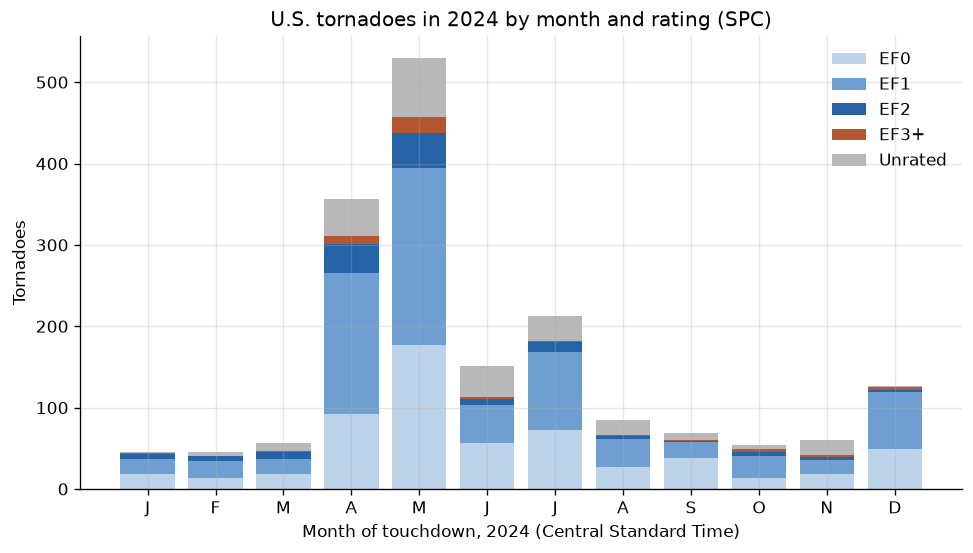

In [5]:
labels = {-9: "Unrated", 0: "EF0", 1: "EF1", 2: "EF2", 3: "EF3", 4: "EF4", 5: "EF5"}
rating = tracks["mag"].map(labels)
monthly = (
    tracks.groupby([tracks["date"].dt.month, rating])
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(1, 13), fill_value=0)
)
monthly["EF3+"] = monthly[[c for c in ("EF3", "EF4", "EF5") if c in monthly]].sum(axis=1)
order = ["EF0", "EF1", "EF2", "EF3+", "Unrated"]
colors = ["#bcd3ea", "#6f9fd0", "#2563a6", "#b45631", "#b8b8b8"]
fig, ax = plt.subplots(layout="constrained")
bottom = pd.Series(0, index=monthly.index)
for name, color in zip(order, colors, strict=True):
    ax.bar(monthly.index, monthly[name], bottom=bottom, color=color, label=name)
    bottom += monthly[name]
ax.set_xticks(range(1, 13), ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_xlabel("Month of touchdown, 2024 (Central Standard Time)")
ax.set_ylabel("Tornadoes")
ax.set_title("U.S. tornadoes in 2024 by month and rating (SPC)")
ax.legend(frameon=False)
plt.show()

In [6]:
totals = monthly[order].sum(axis=1)
spring = totals[4] + totals[5]
print(f"{totals.sum()} tornadoes; April and May: {spring} ({spring / totals.sum():.0%})")
print("By month:", totals.to_dict())
print("By rating:", monthly[order].sum().to_dict())
strong = tracks[tracks["mag"] >= 3]
print(f"{len(strong)} rated EF3 or higher, with {strong['len'].sum():.0f} miles of path")
tracks.nlargest(3, "len")[["date", "time", "st", "mag", "len", "wid", "fat"]]

1791 tornadoes; April and May: 886 (49%)
By month: {1: 45, 2: 45, 3: 56, 4: 356, 5: 530, 6: 151, 7: 213, 8: 85, 9: 69, 10: 54, 11: 60, 12: 127}
By rating: {'EF0': 594, 'EF1': 759, 'EF2': 137, 'EF3+': 47, 'Unrated': 254}
47 rated EF3 or higher, with 907 miles of path


,date,time,st,mag,len,wid,fat
1769,2024-12-28,14:26:00,TX,3,67.88,880,0
1666,2024-10-09,14:33:00,FL,2,65.49,300,0
1286,2024-07-08,13:15:00,LA,2,52.93,800,2


April and May hold half the year's 1,791 tornadoes, and EF0 and EF1 three
quarters of them; 47 were rated EF3 or stronger. December's 127 stand out
after a quiet autumn, and include the year's longest path, 68 miles in Texas
on 28 December. One in seven tornadoes has no rating at all (`-9`), typically
one that crossed open country with nothing a damage survey could rate, so the
unrated share is a reporting category, not a count of weak tornadoes. One
year says nothing about a trend: reporting changed over the decades, and SPC
notes its files serve verification rather than climatology.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. Keep the
manifest and lockfile with your analysis; the citation below is what a
methods section needs, and `usdata cite dataset.yaml` prints the same.

In [7]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:spc-tornado-reports
  NOAA/NWS Storm Prediction Center, Severe Weather Database tornado files, accessed via usdata
  homepage: https://www.spc.noaa.gov/wcm/#data
  license: US Government Work (public domain)
  terms: https://www.weather.gov/disclaimer
  retrieved: 2026-09-24; 1 checksummed asset (230,094 bytes) pinned by usdata 0.26.0
  sources: 1


## What was awkward

- Counting tornadoes needs `sg == 1`. A plain row count adds the state
  segments of multi-state tornadoes and the county-only `sg == -9` rows, and
  nothing in the reader warns about it.
- `-9` is a rating category ("unrated"), not a missing value, so it must not
  be averaged with the EF numbers; the reader leaves it as an integer.
- FIPS codes arrive as integers unless `dtype` says otherwise, which drops
  leading zeros and breaks joins to other county data.
- Every time is Central Standard Time, including tornadoes in other zones;
  the `tz` column says so, but it is easy to miss when joining to UTC data.
- `loss` changed units twice. Before 1996 it is a 0 to 9 damage category;
  the 2010 and 2015 files hold millions of dollars; the 2016 and 2024 files
  hold whole dollars (the largest 2024 value is 514,000,000). The
  [SPC guide](https://docs.usdata.dev/providers/noaa-spc-tornado/) and the
  catalog describe only the first change, and SPC calls damage figures
  unreliable, so this walkthrough leaves them out.
- The file name never changes when SPC revises a year, so without the
  lockfile there is no way to tell which revision an analysis read.
- For county rows with narratives and local times, use
  [Storm Events](https://usdata.dev/datasets/noaa/storm-events/); the
  [severe weather labels guide](https://docs.usdata.dev/guides/severe-weather-labels/)
  compares the two.